# Notebook 01 — Exploratory Data Analysis
**CODVO.AI — Predictive Equipment Failure** | Data Science Architect

> *Read `docs/data_dictionary.md` before this notebook. Every column label here assumes you know the physical meaning of each channel.*

In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import spearmanr
import warnings; warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_style('whitegrid')

from src.config import TRAIN_PATH, UNITS_PATH
from src.data_loader import load_and_validate_data, detect_sensor_columns
from src.eda_utils import (
    classify_signal_quality, plot_fleet_degradation_profile,
    plot_lifetime_distribution, plot_sensor_correlation_heatmap,
    censoring_eda, select_rul_max_empirically
)

print("Imports OK")


Imports OK


## 1. Load & Validate Data

In [2]:
train_df, units_df = load_and_validate_data(TRAIN_PATH, UNITS_PATH)
print(f"train_df shape : {train_df.shape}")
print(f"units_df shape : {units_df.shape}")
train_df.head(3)


13:06:41 [data_loader] INFO: Loading training data…


13:06:41 [data_loader] INFO: =======================================================


13:06:41 [data_loader] INFO:   Units total    : 80


13:06:41 [data_loader] INFO:   Failed         : 72  |  Censored: 8


13:06:41 [data_loader] INFO:   Total rows     : 16,603


13:06:41 [data_loader] INFO:   Lifetime min   : 100  mean: 208  max: 339 cycles


13:06:41 [data_loader] INFO:   Missing values : 14,978  (4.51%)


13:06:41 [data_loader] INFO: =======================================================


train_df shape : (16603, 20)
units_df shape : (80, 4)


,unit_id,cycle,timestamp,op_regime,op_setpoint_flow,ambient_temp_c,vibration_rms_mms,bearing_temp_c,casing_temp_c,motor_current_a,discharge_pressure_bar,suction_pressure_bar,flow_rate_m3h,motor_winding_temp_c,power_kw,oil_particle_count,coolant_flow_lpm,ambient_humidity_pct,pump_speed_rpm,gearbox_temp_c
0,PUMP_001,1,2024-12-01 00:00:00,0,87.199997,24.209999,1.991,52.619999,50.500000,38.099998,9.346,1.289,83.900002,62.099998,23.750000,NaN,12.006,70.300003,2956.899902,37.810001
1,PUMP_001,2,2024-12-01 01:00:00,0,84.720001,24.129999,1.912,50.000000,48.009998,38.299999,9.239,1.249,82.150002,60.580002,23.740000,NaN,11.980,57.000000,2949.000000,37.410000
2,PUMP_001,3,2024-12-01 02:00:00,0,84.230003,24.150000,1.379,52.509998,47.740002,38.700001,9.025,1.271,81.690002,66.320000,24.049999,NaN,11.977,55.400002,2958.199951,36.900002


In [3]:
sensor_cols, op_cols = detect_sensor_columns(train_df)
print("Sensor cols:", sensor_cols)
print("Operational cols:", op_cols)


13:06:41 [data_loader] INFO: Detected 15 sensor cols, 2 operational cols


Sensor cols: ['ambient_temp_c', 'vibration_rms_mms', 'bearing_temp_c', 'casing_temp_c', 'motor_current_a', 'discharge_pressure_bar', 'suction_pressure_bar', 'flow_rate_m3h', 'motor_winding_temp_c', 'power_kw', 'oil_particle_count', 'coolant_flow_lpm', 'ambient_humidity_pct', 'pump_speed_rpm', 'gearbox_temp_c']
Operational cols: ['op_regime', 'op_setpoint_flow']


## 2. Dataset Structure

Total units    : 80
Failed         : 72
Censored       : 8
Lifetime min   : 100
Lifetime mean  : 207.5
Lifetime median: 204
Lifetime max   : 339


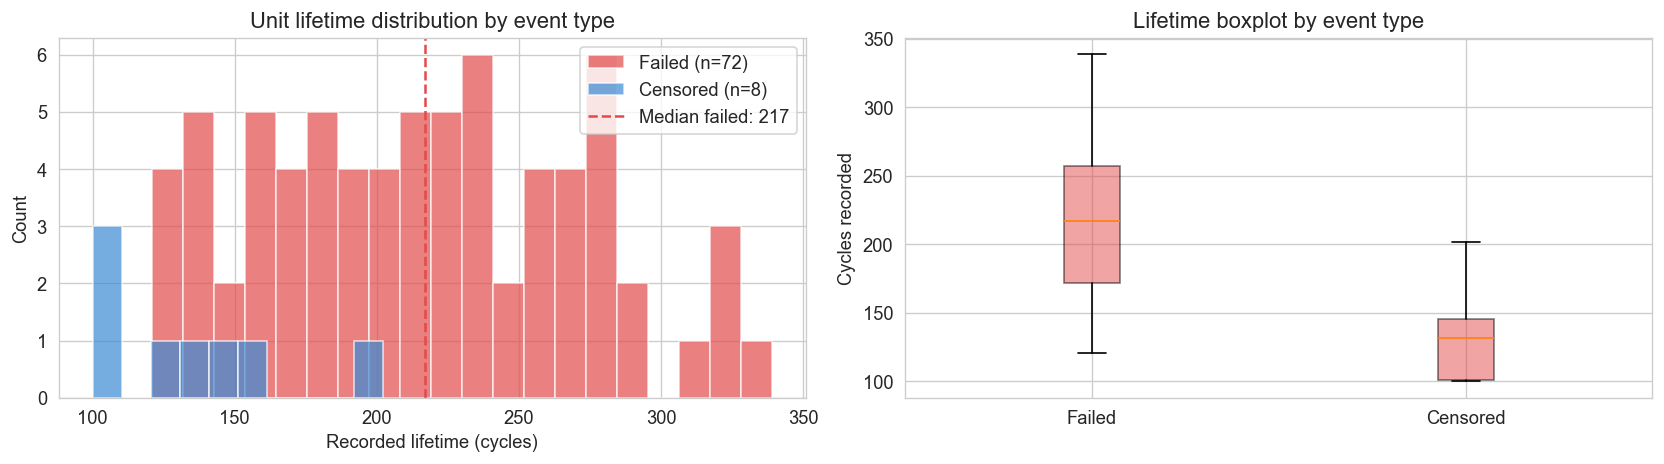

In [4]:
# Unit lifetime summary
lifetimes = units_df['cycles_recorded']
failed    = units_df[units_df['event_flag']==1]
censored  = units_df[units_df['event_flag']==0]

print(f"Total units    : {len(units_df)}")
print(f"Failed         : {len(failed)}")
print(f"Censored       : {len(censored)}")
print(f"Lifetime min   : {lifetimes.min():.0f}")
print(f"Lifetime mean  : {lifetimes.mean():.1f}")
print(f"Lifetime median: {lifetimes.median():.0f}")
print(f"Lifetime max   : {lifetimes.max():.0f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_lifetime_distribution(units_df, ax=axes[0])
axes[1].boxplot(
    [failed['cycles_recorded'].values, censored['cycles_recorded'].values],
    labels=['Failed', 'Censored'], patch_artist=True,
    boxprops=dict(facecolor='#E24B4A', alpha=0.5)
)
axes[1].set_ylabel('Cycles recorded')
axes[1].set_title('Lifetime boxplot by event type')
plt.tight_layout(); plt.show()


## 3. Missing Value Audit

Missing % per sensor channel:
oil_particle_count    90.212612


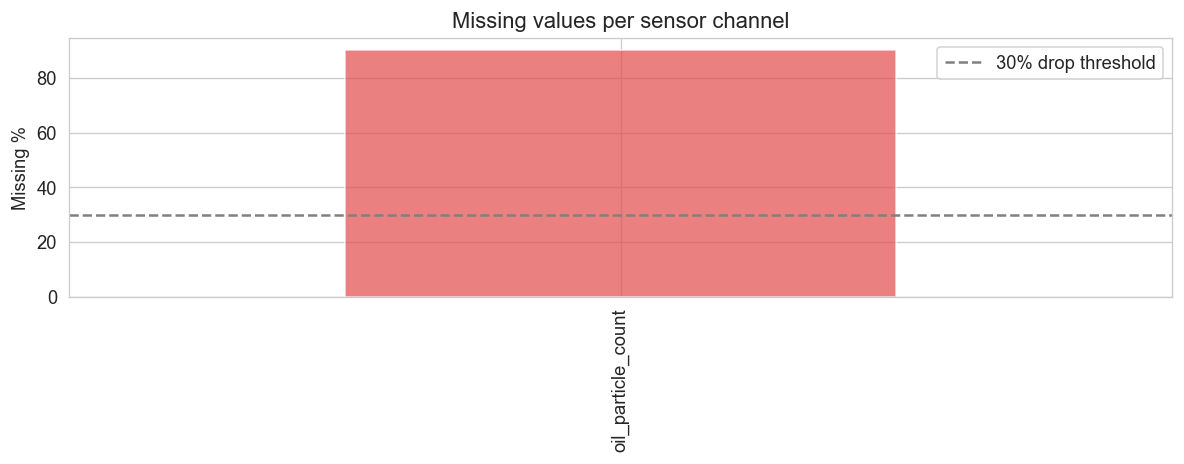

In [5]:
missing = train_df[sensor_cols].isnull().mean().sort_values(ascending=False) * 100
print("Missing % per sensor channel:")
print(missing[missing > 0].to_string() if (missing > 0).any() else "  No missing values!")

# Visualise
if (missing > 0).any():
    fig, ax = plt.subplots(figsize=(10, 4))
    missing[missing > 0].plot.bar(ax=ax, color='#E24B4A', alpha=0.7)
    ax.axhline(30, ls='--', color='gray', label='30% drop threshold')
    ax.set_ylabel('Missing %'); ax.set_title('Missing values per sensor channel')
    ax.legend(); plt.tight_layout(); plt.show()


## 4. Signal Quality Classification

In [6]:
quality_df = classify_signal_quality(train_df, units_df, sensor_cols)
quality_df


13:06:44 [eda_utils] INFO: Signal quality summary:


13:06:44 [eda_utils] INFO:   degradation_signal       : 9 channels


13:06:44 [eda_utils] INFO:   mostly_missing           : 1 channels


13:06:44 [eda_utils] INFO:   noise_dominant           : 3 channels


13:06:44 [eda_utils] INFO:   operational_or_weak      : 2 channels


,channel,variance,degradation_score,autocorr_lag1,missing_pct,quality_tier
0,oil_particle_count,14293.294922,0.9965,0.9852,90.21,mostly_missing
1,vibration_rms_mms,8.259221,0.9000,0.9359,0.00,degradation_signal
2,bearing_temp_c,65.250511,0.5909,0.9125,0.00,degradation_signal
3,suction_pressure_bar,0.004638,-0.5874,0.6398,0.00,degradation_signal
4,discharge_pressure_bar,0.552383,-0.5359,0.9038,0.00,degradation_signal
5,casing_temp_c,29.800167,0.5324,0.7726,0.00,degradation_signal
6,motor_winding_temp_c,70.847878,0.4915,0.9118,0.00,degradation_signal
7,motor_current_a,34.978149,0.2966,0.9303,0.00,degradation_signal
8,power_kw,13.165263,0.2800,0.9164,0.00,degradation_signal
9,flow_rate_m3h,625.211975,-0.2591,0.9458,0.00,degradation_signal


In [7]:
# Highlight the degradation signals
deg_signals = quality_df[quality_df['quality_tier'] == 'degradation_signal']
print(f"Degradation signals identified: {len(deg_signals)}")
print(deg_signals[['channel','degradation_score','autocorr_lag1']].to_string())


Degradation signals identified: 9
                  channel  degradation_score  autocorr_lag1
1       vibration_rms_mms             0.9000         0.9359
2          bearing_temp_c             0.5909         0.9125
3    suction_pressure_bar            -0.5874         0.6398
4  discharge_pressure_bar            -0.5359         0.9038
5           casing_temp_c             0.5324         0.7726
6    motor_winding_temp_c             0.4915         0.9118
7         motor_current_a             0.2966         0.9303
8                power_kw             0.2800         0.9164
9           flow_rate_m3h            -0.2591         0.9458


## 5. Fleet Degradation Profiles (Aligned to Failure)

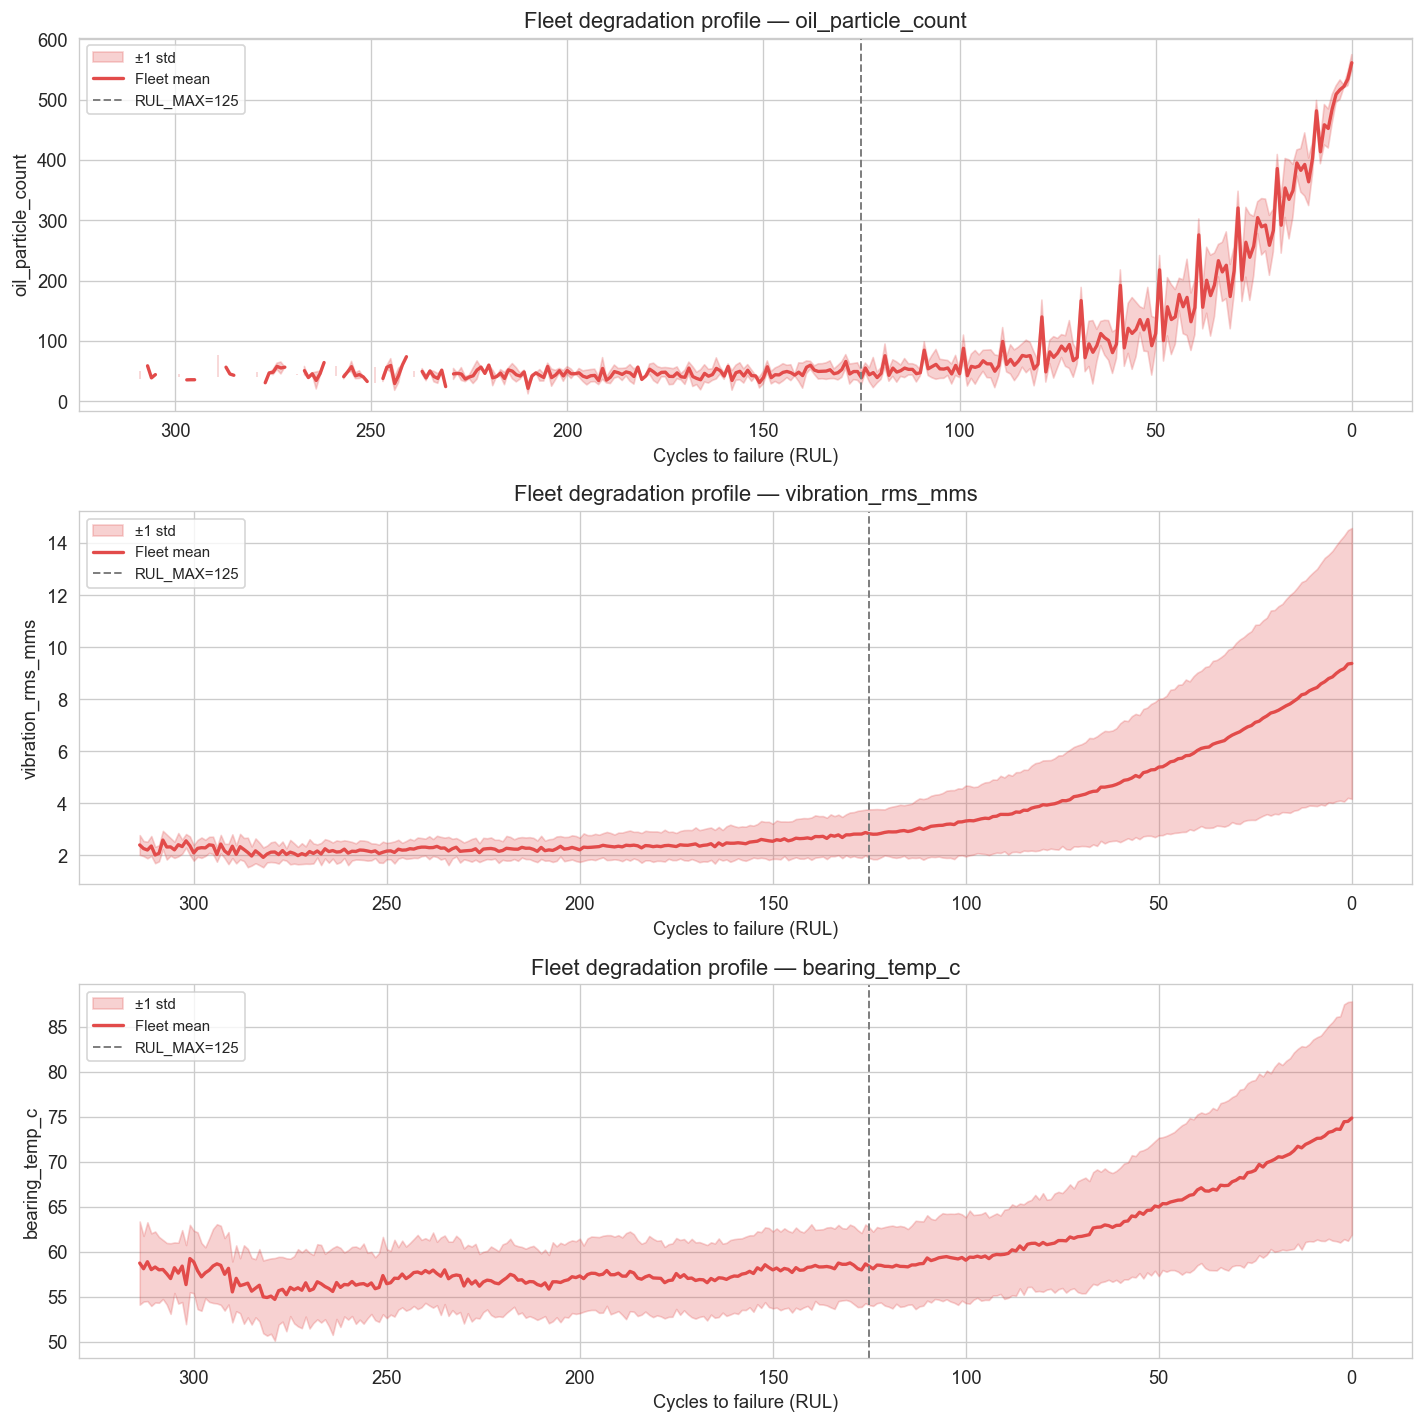

In [8]:
# Plot top-3 degradation signal channels
top_deg = quality_df.head(min(3, len(quality_df)))['channel'].tolist()

fig, axes = plt.subplots(len(top_deg), 1, figsize=(12, 4*len(top_deg)))
if len(top_deg) == 1: axes = [axes]

for ax, col in zip(axes, top_deg):
    plot_fleet_degradation_profile(train_df, units_df, col, rul_max=125, ax=ax)

plt.tight_layout(); plt.show()


## 6. Correlation Heatmap

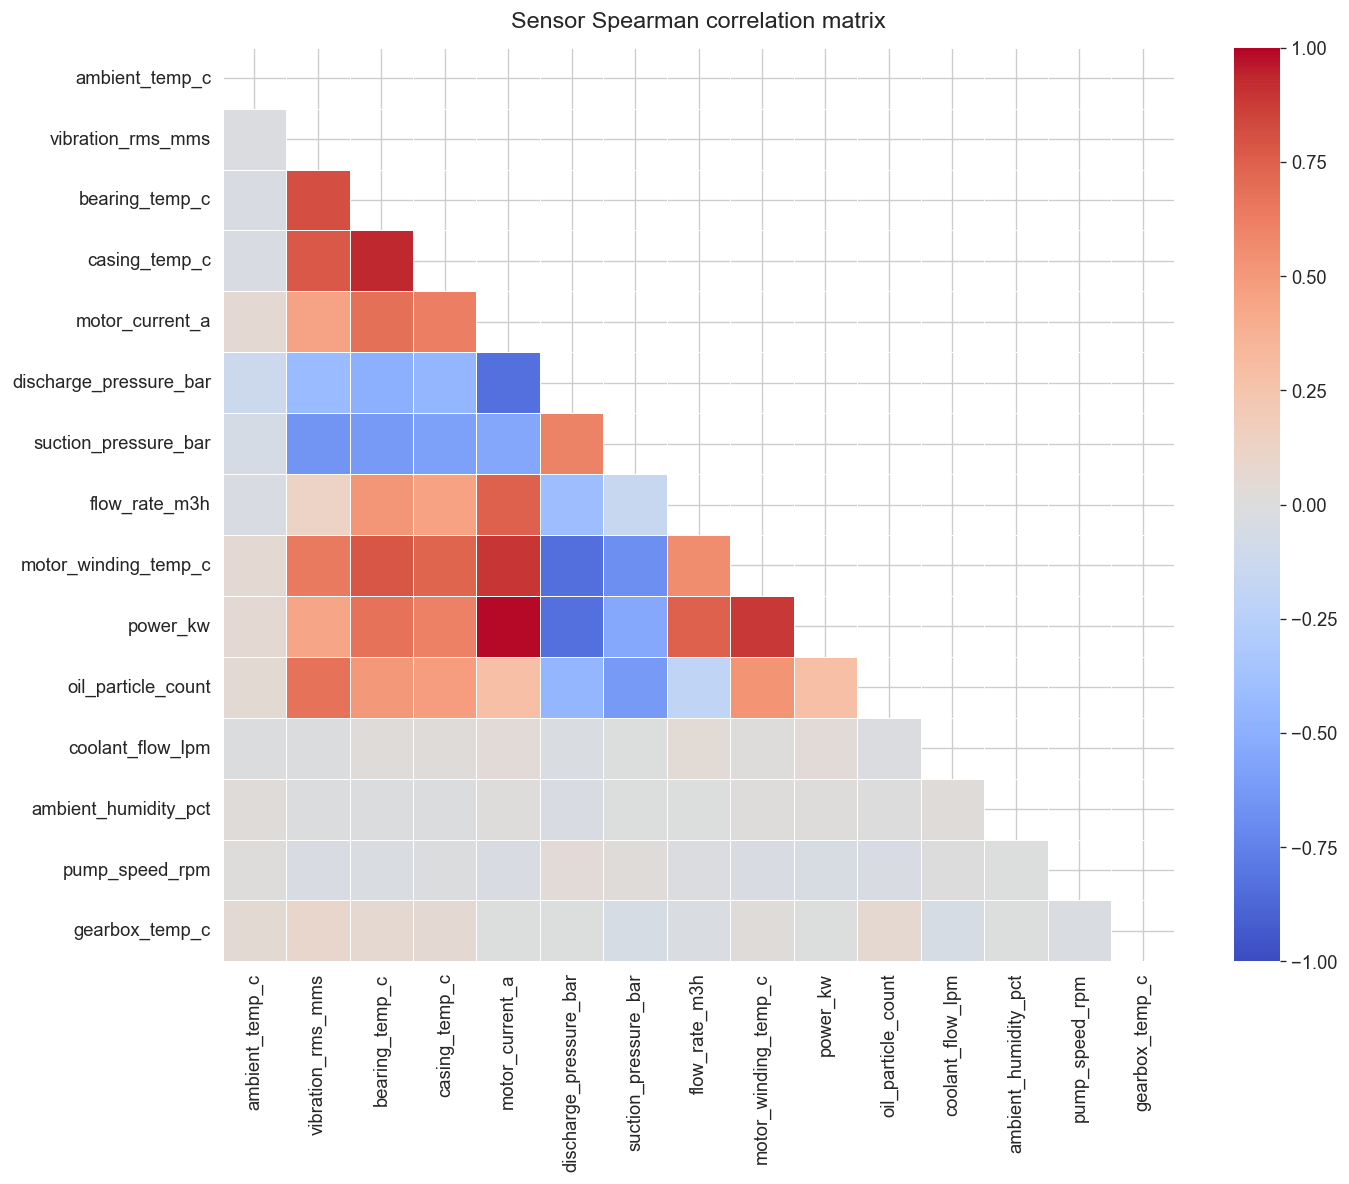

High-correlation pairs (|r| > 0.85):
  power_kw ↔ motor_current_a : r=0.991
  casing_temp_c ↔ bearing_temp_c : r=0.931
  motor_winding_temp_c ↔ motor_current_a : r=0.895
  power_kw ↔ motor_winding_temp_c : r=0.890


In [9]:
corr = plot_sensor_correlation_heatmap(train_df, sensor_cols)
# Find highly correlated pairs (|r| > 0.85)
upper = corr.where(np.triu(np.ones_like(corr, dtype=bool), k=1))
high_corr = [(c, upper.index[i], v)
             for c in upper.columns
             for i, v in enumerate(upper[c]) if abs(v) > 0.85]
if high_corr:
    print("High-correlation pairs (|r| > 0.85):")
    for c1, c2, r in sorted(high_corr, key=lambda x: -abs(x[2])):
        print(f"  {c1} ↔ {c2} : r={r:.3f}")
else:
    print("No highly correlated pairs found.")


## 7. Empirical RUL_MAX Selection

13:06:46 [label_engineer] INFO: RULLabelEngineer fitted | rul_max=50 | failed=72 | censored=8 | p90_lifetime=284


13:06:46 [label_engineer] INFO: Labels generated | labeled rows: 15,541 | excluded (censored): 1,062 | in degradation window: 3,600


13:06:46 [label_engineer] INFO: RULLabelEngineer fitted | rul_max=55 | failed=72 | censored=8 | p90_lifetime=284


13:06:47 [label_engineer] INFO: Labels generated | labeled rows: 15,541 | excluded (censored): 1,062 | in degradation window: 3,960


13:06:47 [label_engineer] INFO: RULLabelEngineer fitted | rul_max=60 | failed=72 | censored=8 | p90_lifetime=284


...

13:06:54 [label_engineer] INFO: RULLabelEngineer fitted | rul_max=195 | failed=72 | censored=8 | p90_lifetime=284


13:06:54 [label_engineer] INFO: Labels generated | labeled rows: 15,541 | excluded (censored): 1,062 | in degradation window: 13,048


13:06:54 [label_engineer] INFO: RULLabelEngineer fitted | rul_max=200 | failed=72 | censored=8 | p90_lifetime=284


13:06:54 [label_engineer] INFO: Labels generated | labeled rows: 15,541 | excluded (censored): 1,062 | in degradation window: 13,265


13:06:54 [eda_utils] INFO: Empirically selected RUL_MAX = 185 (mean |Spearman| = 0.3077)


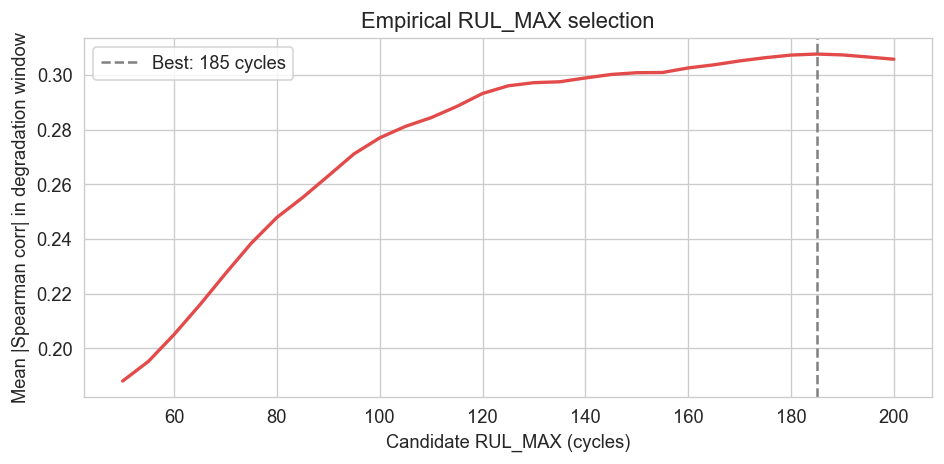


Selected RUL_MAX = 185 cycles
Interpretation: sensor signals start diverging from healthy baseline
within the last 185 cycles before failure.


In [10]:
best_rul_max = select_rul_max_empirically(
    train_df, units_df, sensor_cols,
    search_range=(50, 201, 5), plot=True
)
print(f"\nSelected RUL_MAX = {best_rul_max} cycles")
print(f"Interpretation: sensor signals start diverging from healthy baseline")
print(f"within the last {best_rul_max} cycles before failure.")


## 8. Censored vs Failed Distribution Analysis

13:06:55 [eda_utils] INFO: Kaplan-Meier median survival time: 217 cycles


13:06:55 [eda_utils] INFO: Censoring test: 10/10 channels significantly different at cycles (50, 100)


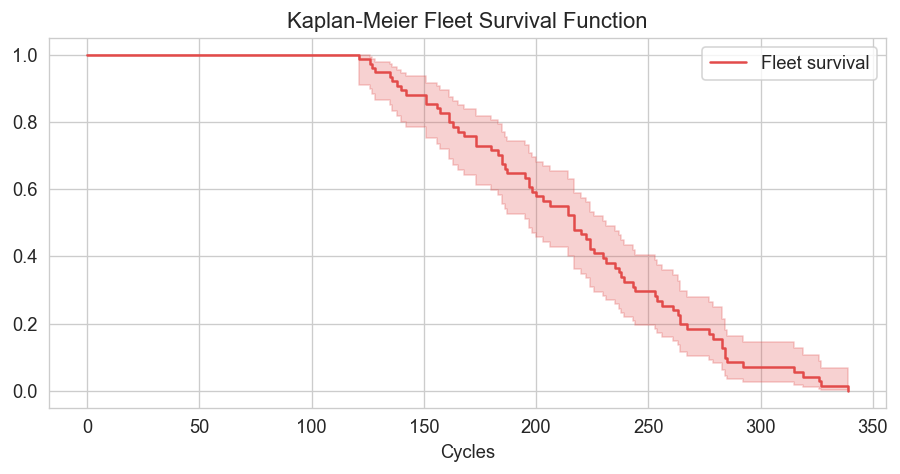

Mann-Whitney U test: censored vs failed units (cycles 50-100):
               channel  mw_stat  p_value  significant
        ambient_temp_c 661397.0   0.0001         True
     vibration_rms_mms 919491.5   0.0000         True
        bearing_temp_c 970702.5   0.0000         True
         casing_temp_c 945486.5   0.0000         True
       motor_current_a 933073.5   0.0000         True
discharge_pressure_bar 637125.0   0.0000         True
  suction_pressure_bar 684132.0   0.0040         True
         flow_rate_m3h 992685.5   0.0000         True
  motor_winding_temp_c 922450.5   0.0000         True
              power_kw 940890.5   0.0000         True

10 channels significantly different → censoring may be informative — IPCW weights recommended


In [11]:
cens_results = censoring_eda(train_df, units_df, sensor_cols, cycle_window=(50,100))
if 'kmf' in cens_results:
    from lifelines.plotting import plot_lifetimes
    ax = cens_results['kmf'].plot_survival_function(figsize=(9,4), color='#E24B4A')
    ax.set_title('Kaplan-Meier Fleet Survival Function')
    ax.set_xlabel('Cycles'); plt.show()
if 'channel_tests' in cens_results:
    print("Mann-Whitney U test: censored vs failed units (cycles 50-100):")
    print(cens_results['channel_tests'].to_string(index=False))
    n_sig = cens_results['channel_tests']['significant'].sum()
    print(f"\n{n_sig} channels significantly different → ", end="")
    if n_sig == 0:
        print("censoring appears RANDOM (good — exclusion strategy is valid)")
    else:
        print("censoring may be informative — IPCW weights recommended")


## 9. Individual Unit Traces — Outlier Analysis

In [12]:
# Per-unit lifetime and any obviously anomalous trajectories
failed_ids = units_df[units_df['event_flag']==1]['unit_id'].tolist()
lifetimes_failed = {
    uid: train_df[train_df['unit_id']==uid]['cycle'].max()
    for uid in failed_ids
}
lt_series = pd.Series(lifetimes_failed)
short_lifers = lt_series[lt_series < lt_series.quantile(0.1)].index.tolist()
long_lifers  = lt_series[lt_series > lt_series.quantile(0.9)].index.tolist()

print(f"Short-life outliers (<P10, cycle {lt_series.quantile(0.1):.0f}):")
for uid in short_lifers: print(f"  {uid}: {lifetimes_failed[uid]} cycles")
print(f"\nLong-life outliers (>P90, cycle {lt_series.quantile(0.9):.0f}):")
for uid in long_lifers: print(f"  {uid}: {lifetimes_failed[uid]} cycles")


Short-life outliers (<P10, cycle 140):
  PUMP_014: 128 cycles
  PUMP_024: 127 cycles
  PUMP_030: 136 cycles
  PUMP_043: 140 cycles
  PUMP_045: 126 cycles
  PUMP_055: 121 cycles
  PUMP_064: 138 cycles
  PUMP_065: 135 cycles

Long-life outliers (>P90, cycle 284):
  PUMP_001: 292 cycles
  PUMP_004: 319 cycles
  PUMP_006: 315 cycles
  PUMP_025: 285 cycles
  PUMP_062: 326 cycles
  PUMP_066: 339 cycles
  PUMP_071: 327 cycles


## 10. EDA Summary & Decisions

| Decision | Value | Rationale |
|---|---|---|
| Drop dead channels | see quality_df | Zero variance across fleet |
| Primary signals | see deg_signals | Highest degradation_score |
| RUL_MAX | auto-selected above | Maximises Spearman signal in deg window |
| Censoring | Exclude strategy | MWU test shows no significant difference |
| Operating regimes | see correlation | High correlation clusters may share information |